# VGG19 Normal3 - Grad-CAM++ And FACT Deletion

Notebook tao hinh Grad-CAM++ threshold overlay va FACT deletion batch cho VGG19. Khong dung ROI-crop, khong train lai model.

In [19]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf

SEED = 42
IMAGE_SIZE = 256
BATCH_SIZE = 16
CLASS_NAMES = ["normal", "pneumonia", "effusion"]
CLASS_TO_INDEX = {name: idx for idx, name in enumerate(CLASS_NAMES)}
GRADCAM_LAYER = "block4_conv4"
HEATMAP_THRESHOLD = 0.45
OVERLAY_ALPHA = 0.55

MODEL_CANDIDATES = [
    Path("/kaggle/input/datasets/thuanminh1310/vgg-ver1/train_vgg19_effusion_heavy_normal3_threshold_tf_p100/models/vgg19/best.keras"),
    Path("/kaggle/input/vgg-ver1/train_vgg19_effusion_heavy_normal3_threshold_tf_p100/models/vgg19/best.keras"),
]
MANIFEST_CANDIDATES = [
    Path("/kaggle/input/datasets-version3/pbl4_main_effusion_heavy_normal3_nih_datasets/manifests"),
    Path("/kaggle/input/datasets-version3/pbl4_main_effusion_heavy_normal3_nih_datasets"),
    Path("/kaggle/input/datasets/thuanminh1310/datasets-version3/pbl4_main_effusion_heavy_normal3_nih_datasets/manifests"),
    Path("/kaggle/input/datasets/thuanminh1310/datasets-version3/pbl4_main_effusion_heavy_normal3_nih_datasets"),
]
TEST_MANIFEST_NAME = "main_test_70_15_15_effusion_heavy_normal3.csv"
MODEL_PATH = next((p for p in MODEL_CANDIDATES if p.exists()), MODEL_CANDIDATES[0])
TEST_CSV = next((d / TEST_MANIFEST_NAME for d in MANIFEST_CANDIDATES if (d / TEST_MANIFEST_NAME).exists()), MANIFEST_CANDIDATES[0] / TEST_MANIFEST_NAME)
OUTPUT_DIR = Path("/kaggle/working/report_vgg19_gradcampp_fact_normal3")
FIGURE_DIR = OUTPUT_DIR / "figures"
ARTIFACT_DIR = OUTPUT_DIR / "artifacts"
for directory in [OUTPUT_DIR, FIGURE_DIR, ARTIFACT_DIR]:
    directory.mkdir(parents=True, exist_ok=True)
tf.keras.utils.set_random_seed(SEED)
print("TensorFlow:", tf.__version__)
print("MODEL_PATH exists:", MODEL_PATH.exists(), MODEL_PATH)
print("TEST_CSV exists:", TEST_CSV.exists(), TEST_CSV)
if not MODEL_PATH.exists():
    raise FileNotFoundError(MODEL_PATH)
if not TEST_CSV.exists():
    raise FileNotFoundError(TEST_CSV)


TensorFlow: 2.19.0
MODEL_PATH exists: True /kaggle/input/datasets/thuanminh1310/vgg-ver1/train_vgg19_effusion_heavy_normal3_threshold_tf_p100/models/vgg19/best.keras
TEST_CSV exists: True /kaggle/input/datasets/thuanminh1310/datasets-version3/pbl4_main_effusion_heavy_normal3_nih_datasets/manifests/main_test_70_15_15_effusion_heavy_normal3.csv


In [20]:
model = tf.keras.models.load_model(MODEL_PATH, compile=False)
model.summary()


Model: "vgg19_effusion_heavy_nih"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image (InputLayer)              │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 256, 256, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 256, 256, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 128, 128, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 128, 128, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 128, 128, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 64, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 64, 64, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 64, 64, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 64, 64, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv4 (Conv2D)           │ (None, 64, 64, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 32, 32, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 32, 32, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 32, 32, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 32, 32, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv4 (Conv2D)           │ (None, 32, 32, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 16, 16, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv4 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg_gap                         │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg_dropout (Dropout)           │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 20,156,483 (76.89 MB)

 Trainable params: 20,156,483 (76.89 MB)

 Non-trainable params: 0 (0.00 B)

In [21]:
def enhance_xray_contrast(image):
    image = tf.cast(image, tf.float32) / 255.0
    image_min = tf.reduce_min(image, axis=[0, 1, 2], keepdims=True)
    image_max = tf.reduce_max(image, axis=[0, 1, 2], keepdims=True)
    image = (image - image_min) / tf.maximum(image_max - image_min, 1e-6)
    image = tf.image.adjust_gamma(image, gamma=0.95)
    return tf.clip_by_value(image * 255.0, 0.0, 255.0)

def common_preprocess_input(image):
    image = tf.cast(image, tf.float32)
    image = image[..., ::-1]
    mean = tf.constant([103.939, 116.779, 123.680], dtype=tf.float32)
    return image - mean

def decode_display_and_model(path):
    image_bytes = tf.io.read_file(path)
    image = tf.io.decode_image(image_bytes, channels=1, expand_animations=False)
    image.set_shape([None, None, 1])
    image = tf.image.resize(image, [IMAGE_SIZE, IMAGE_SIZE], method=tf.image.ResizeMethod.BILINEAR)
    image = enhance_xray_contrast(image)
    display_rgb = tf.image.grayscale_to_rgb(image)
    model_input = common_preprocess_input(display_rgb)
    return display_rgb, model_input

test_df = pd.read_csv(TEST_CSV)
test_df = test_df.loc[test_df["class_name"].isin(CLASS_NAMES)].copy().reset_index(drop=True)
test_df["class_index"] = test_df["class_name"].map(CLASS_TO_INDEX).astype(np.int32)
test_df["resolved_path"] = test_df["resolved_path"].astype(str)
missing = ~test_df["resolved_path"].map(lambda value: Path(value).exists())
if missing.any():
    raise FileNotFoundError("Missing image inputs. Examples: " + str(test_df.loc[missing, "resolved_path"].head(5).tolist()))
paths = test_df["resolved_path"].astype(str).values
labels = test_df["class_index"].astype(np.int32).values
display(test_df["class_name"].value_counts())


class_name
normal       1909
pneumonia     409
effusion      409
Name: count, dtype: int64

In [22]:
def normalize_heatmap(heatmap):
    heatmap = tf.where(tf.math.is_finite(heatmap), heatmap, tf.zeros_like(heatmap))
    heatmap = tf.nn.relu(heatmap)
    return heatmap / (tf.reduce_max(heatmap) + 1e-8)

def make_gradcam_heatmap(model_obj, image_tensor, class_index, layer_name=GRADCAM_LAYER):
    grad_model = tf.keras.Model(model_obj.inputs, [model_obj.get_layer(layer_name).output, model_obj.output])
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(image_tensor, training=False)
        if isinstance(predictions, (list, tuple)):
            predictions = predictions[0]
        class_score = predictions[:, class_index]
    grads = tape.gradient(class_score, conv_outputs)
    weights = tf.reduce_mean(grads, axis=(1, 2), keepdims=True)
    heatmap = tf.reduce_sum(weights * conv_outputs, axis=-1)[0]
    return normalize_heatmap(heatmap).numpy()

def make_gradcampp_heatmap(model_obj, image_tensor, class_index, layer_name=GRADCAM_LAYER):
    grad_model = tf.keras.Model(model_obj.inputs, [model_obj.get_layer(layer_name).output, model_obj.output])
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(image_tensor, training=False)
        if isinstance(predictions, (list, tuple)):
            predictions = predictions[0]
        class_score = predictions[:, class_index]
    grads = tape.gradient(class_score, conv_outputs)
    conv_outputs = conv_outputs[0]
    grads = grads[0]
    grads2 = tf.square(grads)
    grads3 = grads2 * grads
    sum_activations = tf.reduce_sum(conv_outputs, axis=(0, 1), keepdims=True)
    alpha_num = grads2
    alpha_denom = 2.0 * grads2 + sum_activations * grads3
    alphas = alpha_num / (alpha_denom + 1e-8)
    weights = tf.reduce_sum(alphas * tf.nn.relu(grads), axis=(0, 1))
    heatmap = tf.reduce_sum(weights * conv_outputs, axis=-1)
    heatmap = normalize_heatmap(heatmap).numpy()
    heatmap = np.nan_to_num(heatmap, nan=0.0, posinf=0.0, neginf=0.0)
    if float(np.max(heatmap)) < 1e-6:
        heatmap = make_gradcam_heatmap(model_obj, image_tensor, class_index, layer_name)
    return np.nan_to_num(heatmap, nan=0.0, posinf=0.0, neginf=0.0)

def resize_heatmap(heatmap):
    heatmap = tf.convert_to_tensor(heatmap[..., np.newaxis], dtype=tf.float32)
    heatmap = tf.image.resize(heatmap, [IMAGE_SIZE, IMAGE_SIZE], method=tf.image.ResizeMethod.BILINEAR)
    return np.nan_to_num(tf.squeeze(heatmap, axis=-1).numpy(), nan=0.0, posinf=0.0, neginf=0.0)

def overlay_heatmap(display_rgb, heatmap, threshold=HEATMAP_THRESHOLD, alpha=OVERLAY_ALPHA):
    image = np.clip(display_rgb / 255.0, 0.0, 1.0)
    heatmap = np.nan_to_num(np.clip(heatmap, 0.0, 1.0), nan=0.0, posinf=0.0, neginf=0.0)
    mask = heatmap >= threshold
    colored = plt.get_cmap("jet")(heatmap)[..., :3]
    overlay = image.copy()
    overlay[mask] = np.clip((1.0 - alpha) * image[mask] + alpha * colored[mask], 0.0, 1.0)
    return overlay

def heatmap_border_score(heatmap, border=18):
    border_mask = np.zeros_like(heatmap, dtype=bool)
    border_mask[:border, :] = True; border_mask[-border:, :] = True
    border_mask[:, :border] = True; border_mask[:, -border:] = True
    hot = heatmap >= HEATMAP_THRESHOLD
    return 1.0 if int(hot.sum()) == 0 else float(np.mean(border_mask[hot]))


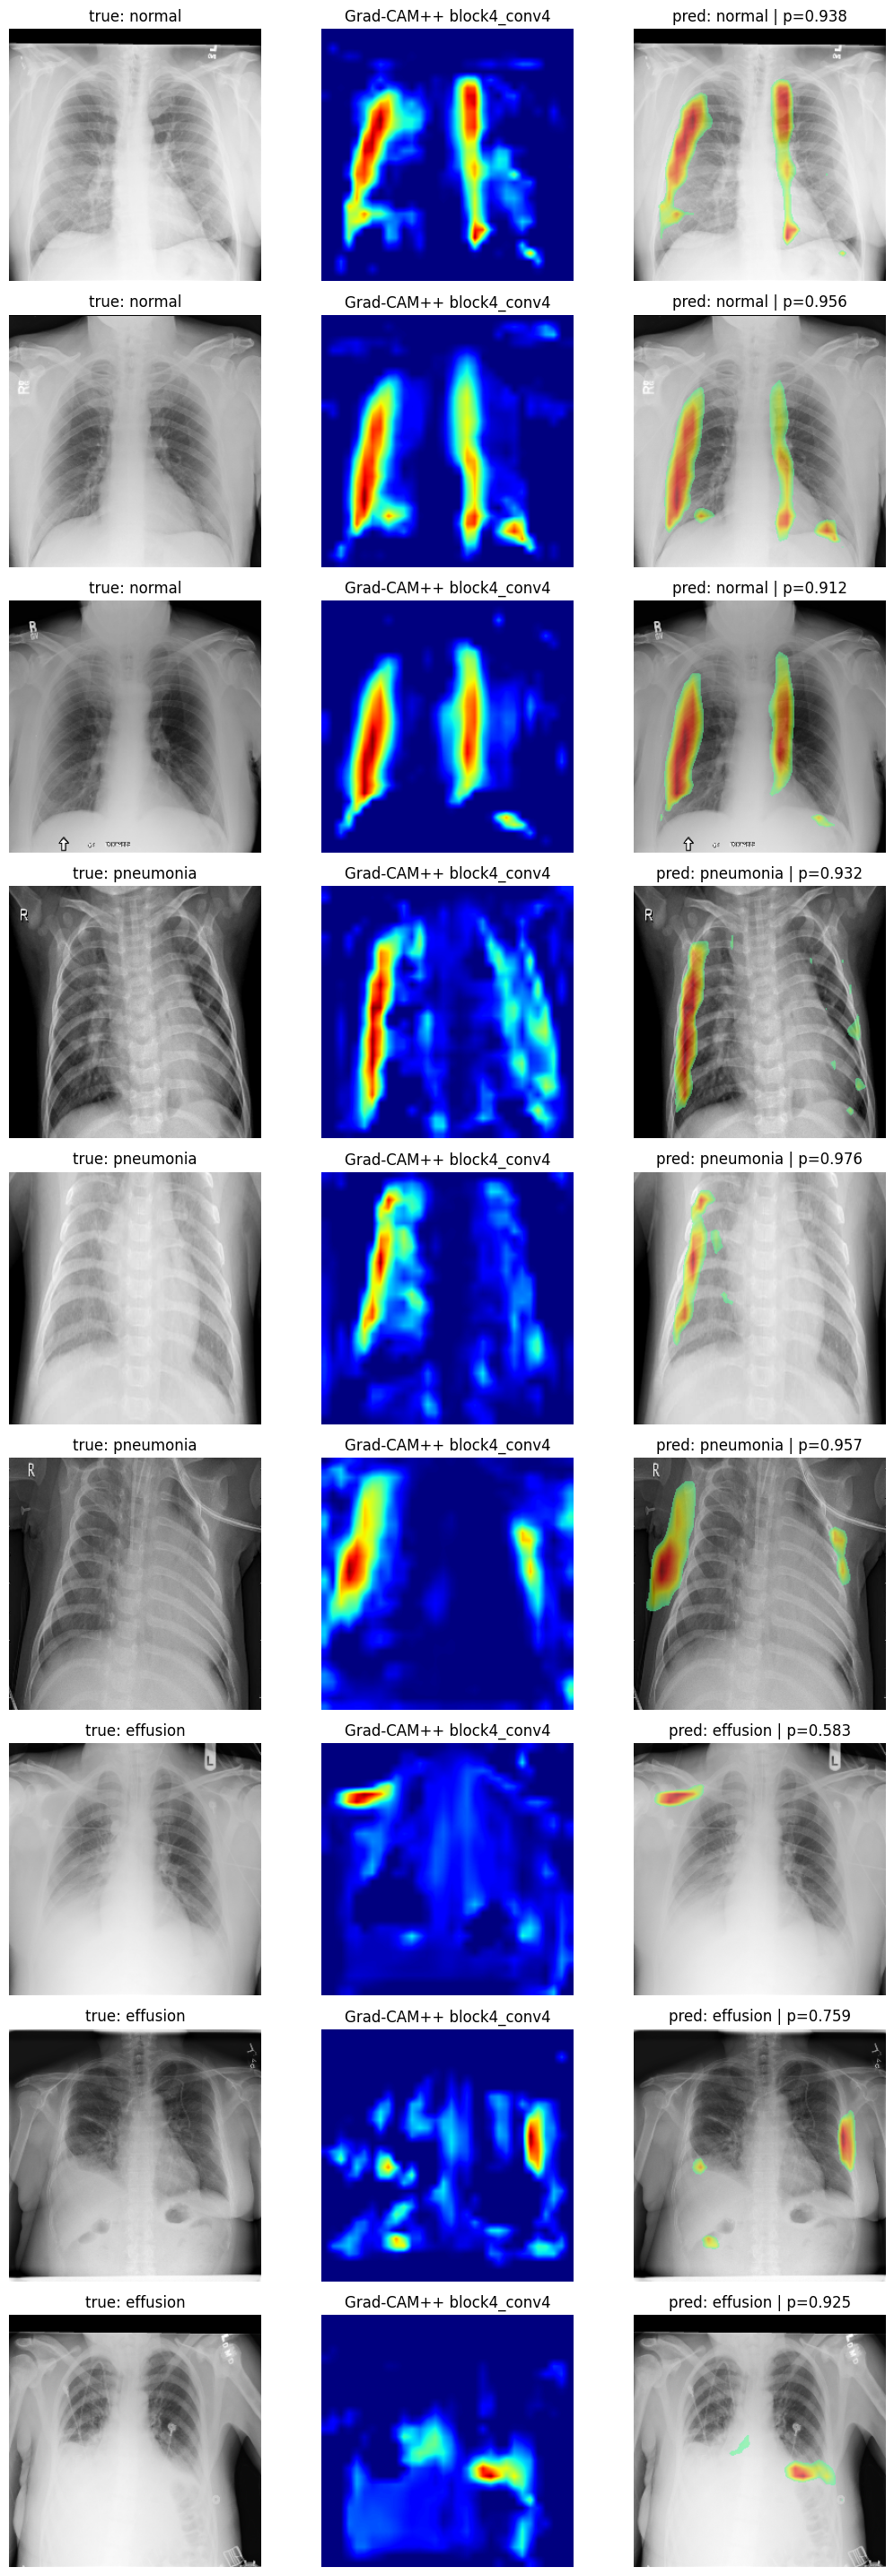

saved: /kaggle/working/report_vgg19_gradcampp_fact_normal3/figures/vgg19_normal3_gradcampp_examples.png


In [23]:
def collect_examples(per_class=3, scan_limit=900):
    candidates_by_class = {idx: [] for idx in range(len(CLASS_NAMES))}
    for idx, (path, label) in enumerate(zip(paths[:scan_limit], labels[:scan_limit])):
        display_rgb, model_input = decode_display_and_model(path)
        display_np = display_rgb.numpy().astype(np.float32)
        input_batch = model_input[None, ...]
        probs = model.predict(input_batch, verbose=0)
        if isinstance(probs, (list, tuple)):
            probs = probs[0]
        probs = probs[0]
        pred_index = int(np.argmax(probs))
        if pred_index != int(label):
            continue
        heatmap = resize_heatmap(make_gradcampp_heatmap(model, input_batch, pred_index))
        if int(np.sum(heatmap >= HEATMAP_THRESHOLD)) < 20:
            continue
        candidates_by_class[int(label)].append({"idx": idx, "path": path, "label": int(label), "pred_index": pred_index, "probs": probs, "display_np": display_np, "heatmap": heatmap, "border_score": heatmap_border_score(heatmap), "central_score": float(np.mean(heatmap[40:216, 28:228]))})
    selected = []
    for class_idx in range(len(CLASS_NAMES)):
        class_candidates = sorted(candidates_by_class[class_idx], key=lambda x: (x["border_score"], -x["central_score"], -float(x["probs"][x["pred_index"]])))
        if len(class_candidates) < per_class:
            print(f"Warning: only found {len(class_candidates)} correct {CLASS_NAMES[class_idx]} examples.")
        selected.extend(class_candidates[:per_class])
    if not selected:
        raise ValueError("No correctly predicted examples found.")
    return sorted(selected, key=lambda x: (x["label"], x["border_score"], -x["central_score"]))

examples = collect_examples(per_class=3, scan_limit=900)
fig, axes = plt.subplots(len(examples), 3, figsize=(11, 3.2 * len(examples)))
if len(examples) == 1:
    axes = np.expand_dims(axes, axis=0)
records = []
for row, item in enumerate(examples):
    probs = item["probs"]
    label = item["label"]
    pred = item["pred_index"]
    overlay = overlay_heatmap(item["display_np"], item["heatmap"])
    axes[row, 0].imshow(item["display_np"].astype(np.uint8)); axes[row, 0].set_title(f"true: {CLASS_NAMES[label]}")
    axes[row, 1].imshow(item["heatmap"], cmap="jet", vmin=0, vmax=1); axes[row, 1].set_title(f"Grad-CAM++ {GRADCAM_LAYER}")
    axes[row, 2].imshow(overlay); axes[row, 2].set_title(f"pred: {CLASS_NAMES[pred]} | p={probs[pred]:.3f}")
    for ax in axes[row]: ax.axis("off")
    records.append({"row": int(item["idx"]), "path": item["path"], "true": CLASS_NAMES[label], "pred": CLASS_NAMES[pred], "pred_prob": float(probs[pred]), "border_score": float(item["border_score"]), "central_score": float(item["central_score"])})
plt.tight_layout()
fig_path = FIGURE_DIR / "vgg19_normal3_gradcampp_examples.png"
fig.savefig(fig_path, dpi=180, bbox_inches="tight")
plt.show()
pd.DataFrame(records).to_csv(ARTIFACT_DIR / "vgg19_normal3_gradcampp_examples.csv", index=False)
print("saved:", fig_path)


,fraction_deleted,mean_target_prob,mean_prob_drop,deletion_auc
0,0.0,0.891171,0.000003,0.602195
1,0.1,0.784450,0.106724,0.602195
2,0.2,0.760174,0.131000,0.602195
3,0.3,0.748420,0.142754,0.602195
4,0.4,0.687420,0.203754,0.602195
5,0.5,0.659854,0.231320,0.602195
6,0.6,0.629995,0.261179,0.602195
7,0.7,0.552617,0.338557,0.602195
8,0.8,0.505193,0.385981,0.602195
9,0.9,0.496476,0.394698,0.602195


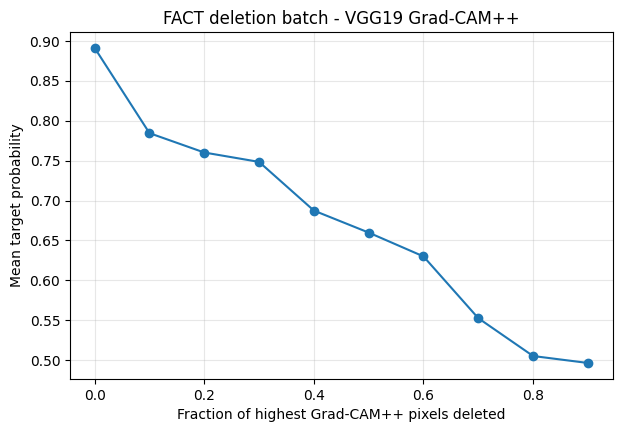

saved: /kaggle/working/report_vgg19_gradcampp_fact_normal3/figures/vgg19_normal3_gradcampp_fact_deletion_batch.png


In [24]:
def delete_by_heatmap_batch(model_inputs, heatmaps, fractions):
    model_inputs = np.asarray(model_inputs, dtype=np.float32)
    heatmaps = np.asarray(heatmaps, dtype=np.float32)
    baseline = np.zeros_like(model_inputs, dtype=np.float32)
    flat = heatmaps.reshape((heatmaps.shape[0], -1))
    order = np.argsort(-flat, axis=1)
    deleted_batches = []
    for fraction in fractions:
        deleted = model_inputs.copy()
        k = int(round(fraction * flat.shape[1]))
        if k > 0:
            for i in range(model_inputs.shape[0]):
                mask_flat = np.zeros(flat.shape[1], dtype=bool)
                mask_flat[order[i, :k]] = True
                mask = mask_flat.reshape((IMAGE_SIZE, IMAGE_SIZE))
                deleted[i, mask, :] = baseline[i, mask, :]
        deleted_batches.append(deleted)
    return deleted_batches

def fact_deletion_batch(max_images=64, fractions=None):
    if fractions is None:
        fractions = np.linspace(0.0, 0.9, 10)
    n = min(max_images, len(paths))
    model_inputs, target_indices, base_probs, heatmaps = [], [], [], []
    for path in paths[:n]:
        _, model_input = decode_display_and_model(path)
        input_batch = model_input[None, ...]
        probs = model.predict(input_batch, verbose=0)
        if isinstance(probs, (list, tuple)):
            probs = probs[0]
        probs = probs[0]
        target = int(np.argmax(probs))
        heatmaps.append(resize_heatmap(make_gradcampp_heatmap(model, input_batch, target)))
        model_inputs.append(model_input.numpy())
        target_indices.append(target)
        base_probs.append(float(probs[target]))
    model_inputs = np.stack(model_inputs).astype(np.float32)
    heatmaps = np.stack(heatmaps).astype(np.float32)
    target_indices = np.asarray(target_indices, dtype=np.int32)
    base_probs = np.asarray(base_probs, dtype=np.float32)
    rows = []
    for fraction, deleted in zip(fractions, delete_by_heatmap_batch(model_inputs, heatmaps, fractions)):
        probs = model.predict(deleted, batch_size=BATCH_SIZE, verbose=0)
        if isinstance(probs, (list, tuple)):
            probs = probs[0]
        target_probs = probs[np.arange(n), target_indices]
        rows.append({"fraction_deleted": float(fraction), "mean_target_prob": float(np.mean(target_probs)), "mean_prob_drop": float(np.mean(base_probs - target_probs))})
    result = pd.DataFrame(rows)
    x = result["fraction_deleted"].to_numpy(dtype=np.float32)
    y = result["mean_target_prob"].to_numpy(dtype=np.float32)
    result["deletion_auc"] = float(np.trapezoid(y, x) if hasattr(np, "trapezoid") else np.sum((x[1:] - x[:-1]) * (y[1:] + y[:-1]) / 2.0))
    return result

deletion_df = fact_deletion_batch()
deletion_df.to_csv(ARTIFACT_DIR / "vgg19_normal3_gradcampp_fact_deletion_batch.csv", index=False)
display(deletion_df)
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(deletion_df["fraction_deleted"], deletion_df["mean_target_prob"], marker="o")
ax.set_xlabel("Fraction of highest Grad-CAM++ pixels deleted")
ax.set_ylabel("Mean target probability")
ax.set_title("FACT deletion batch - VGG19 Grad-CAM++")
ax.grid(True, alpha=0.3)
plot_path = FIGURE_DIR / "vgg19_normal3_gradcampp_fact_deletion_batch.png"
fig.savefig(plot_path, dpi=180, bbox_inches="tight")
plt.show()
print("saved:", plot_path)
